# How to interpret the shaded lightcone visualizations

The package provides two ways to look at a shaded lightcone:

- `draw_shaded_lightcone` overlays the bounds onto the circuit diagram. THis is best for circuits on a 1D
  chain of qubits, where the circuit diagram and the physical layout agree.
- `animate_shaded_lightcone` projects the bounds onto the QPU's coupling map and steps through the
  circuit layer by layer. This is best when the qubit connectivity is more than a 1D line, where a circuit
  diagram stops conveying which qubits are neighbors.

Both visualizations show the same underlying numbers. This guide covers what those numbers mean, and explains the details
that are easy to misread.

## Setup

Use the same Trotterized Ising circuit and observable as the [quickstart guide](quickstart.ipynb).

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, PauliLindbladMap, QubitSparsePauliList
from qiskit_addon_slc.bounds import (
    compute_backward_bounds,
    compute_forward_bounds,
    merge_bounds,
)
from qiskit_addon_slc.utils import generate_noise_model_paulis
from samplomatic.transpiler import generate_boxing_pass_manager
from samplomatic.utils import find_unique_box_instructions


def trotter_ising_circuit(num_qubits, num_steps, rx_angle, rzz_angle):
    """Trotterized transverse-field Ising evolution on a 1D chain."""
    circuit = QuantumCircuit(num_qubits)
    for _ in range(num_steps):
        circuit.rx(rx_angle, range(num_qubits))
        circuit.barrier()
        for start in (0, 1):  # even then odd bonds
            for i in range(start, num_qubits - 1, 2):
                circuit.rzz(rzz_angle, i, i + 1)
        circuit.barrier()
    return circuit


num_qubits = 10
circuit = trotter_ising_circuit(num_qubits, num_steps=4, rx_angle=np.pi / 16, rzz_angle=-np.pi / 3)
observable = Pauli("I" * num_qubits).compose("Z", [num_qubits // 2])

boxing_pass = generate_boxing_pass_manager(
    inject_noise_targets="all",
    inject_noise_strategy="individual_modification",
    inject_noise_site="after",
    twirling_strategy="active",
    remove_barriers="never",
)
boxed_circuit = boxing_pass.run(circuit)
noise_model_paulis = generate_noise_model_paulis(find_unique_box_instructions(boxed_circuit))

forward_bounds = compute_forward_bounds(boxed_circuit, noise_model_paulis, observable)
backward_bounds = compute_backward_bounds(boxed_circuit, noise_model_paulis)

rng = np.random.default_rng(42)
noise_rates = {
    layer: PauliLindbladMap.from_components(
        rng.random(len(terms)) * 5e-3,
        QubitSparsePauliList.from_sparse_list(terms.to_sparse_list(), terms.num_qubits),
    )
    for layer, terms in noise_model_paulis.items()
}
merged_bounds = merge_bounds(boxed_circuit, forward_bounds, backward_bounds, noise_rates)
print(f"observable: Z on qubit {num_qubits // 2}")

Optimal spacetime partitioning not implemented! Just partitioning list of noisy boxes.


observable: Z on qubit 5


## `draw_shaded_lightcone`

Each noisy box is shaded by the bound on the errors occurring there: bright means a large bound, and
a box fading into the background means its errors have little effect on the observable. Those faded
boxes are the candidates for dropping from the mitigated noise model.

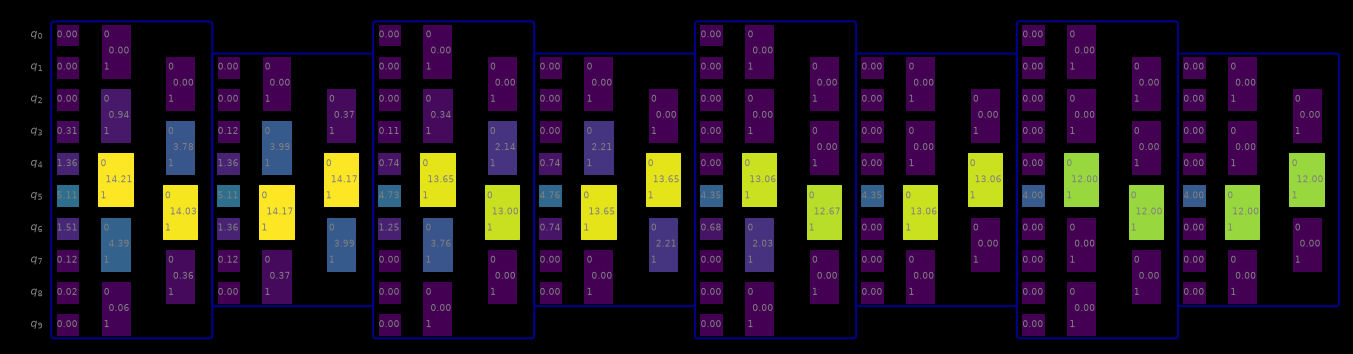

In [2]:
from qiskit_addon_slc.visualization import draw_shaded_lightcone

draw_shaded_lightcone(boxed_circuit, merged_bounds, noise_model_paulis, fold=-1, scale=0.5)

### Important notes

**1. Each number is a sum over the error terms sharing a support.** Without a filter, the bounds of
every error term acting on the same qubit, or on the same pair of qubits, are added into one value:
all three Pauli types on a qubit, and all nine on a pair. That has two consequences. A value can
exceed 2.0, even though no single term's bound can (a box labelled `4.5` is several terms adding up,
not a violated bound). The figure cannot tell you whether a large value comes from one Pauli
type or from several comparable ones; the next section shows how to separate them.

**2. The color scale starts at 2.0 and grows with the data.** The scale runs from 0 to the
`"max_bound"` entry of the overlaid circuit's metadata, which is the larger of 2.0 and the largest
value shown. Unfiltered sums often exceed 2.0, so the scale stretches to fit them, and the same
color can stand for different values in different figures. When every value is small, the
scale stays at 2.0 and everything looks uniformly dark (that is the scale reflecting the absolute
size, not a rendering fault).

### Separating the Pauli types

Use `pauli_filter` to see one type at a time. An integer selects a Pauli weight; a string selects
a specific Pauli, matched against each noise term **reduced to its own non-identity support**. So
`"X"` selects every single-qubit $X$ error, regardless of which qubit it acts on, and `"XX"` selects the
weight-2 ones (a full-width label like `"XII"` matches nothing).

In [3]:
from qiskit_addon_slc.visualization import accumulate_filtered_bounds

box_id = next(iter(merged_bounds))
print(f"single-qubit supports of box {box_id!r}:\n")
print(f"{'filter':>8}  bounds per qubit")
for pauli_filter in (None, 1, "X", "Y", "Z"):
    filtered = accumulate_filtered_bounds(
        boxed_circuit, merged_bounds, noise_model_paulis, pauli_filter
    )
    per_qubit = {
        support[0]: round(float(bound), 3)
        for support, bound in sorted(filtered[box_id].items())
        if len(support) == 1
    }
    print(f"{pauli_filter!s:>8}  {per_qubit}")

single-qubit supports of box 'm0':

  filter  bounds per qubit
    None  {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.312, 4: 1.355, 5: 5.111, 6: 1.506, 7: 0.124, 8: 0.019, 9: 0.0}
       1  {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.312, 4: 1.355, 5: 5.111, 6: 1.506, 7: 0.124, 8: 0.019, 9: 0.0}
       X  {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.153, 4: 0.577, 5: 2.0, 6: 0.702, 7: 0.056, 8: 0.01, 9: 0.0}
       Y  {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.148, 4: 0.607, 5: 2.0, 6: 0.631, 7: 0.057, 8: 0.01, 9: 0.0}
       Z  {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.011, 4: 0.172, 5: 1.111, 6: 0.172, 7: 0.011, 8: 0.0, 9: 0.0}


The unfiltered row is the sum of the three Pauli types below it. Filtering is the only way to tell
whether a large unfiltered value comes from one dominant error type or from several comparable ones.
That matters, because the mitigation acts per term, not per site.

Passing the same filter to `draw_shaded_lightcone` records it in the figure title, so a filtered
figure cannot be mistaken for an unfiltered one:

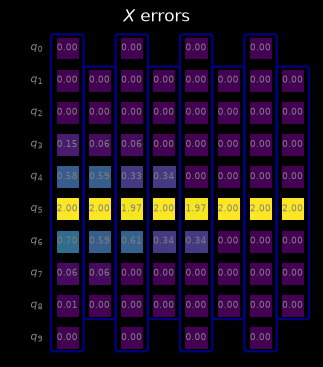

In [4]:
draw_shaded_lightcone(
    boxed_circuit, merged_bounds, noise_model_paulis, pauli_filter="X", fold=-1, scale=0.5
)

This figure looks quite different from the unfiltered one above, and not only because it shows
fewer values. Each placeholder in these figures stands for one support: a single qubit, or a pair of
qubits. Without a filter, a box shows a placeholder on every qubit and on every pair of neighboring
qubits, so it spreads over several columns. With `"X"`, only the single-qubit supports remain, and
each box shrinks to a single column.

Neither picture shows what PEC actually applies though. The placeholders are a way to display
bounds, not anti-noise gates. During the experiment, every box whose error terms are mitigated is
treated as a single layer of two-qubit gates, and the anti-noise Paulis sampled for its error terms
are composed into one Pauli that is applied to that layer as a whole.

## `animate_shaded_lightcone`

On a device whose connectivity is not a 1D line, a circuit diagram no longer shows which qubits are
neighbors, so the spatial spread of the lightcone becomes impossible to read.
`animate_shaded_lightcone` instead draws the QPU's coupling map and animates the bounds across it,
one noisy box per frame.

It needs a `CouplingMap`, which it lays out on a grid by embedding the device graph, so it handles both 
heavy-hex and square connectivity.

<div class="alert alert-info">

**Note:** In this rendered documentation the animation is static. The slider and play button only
work when the notebook runs interactively, for example in Jupyter.

</div>

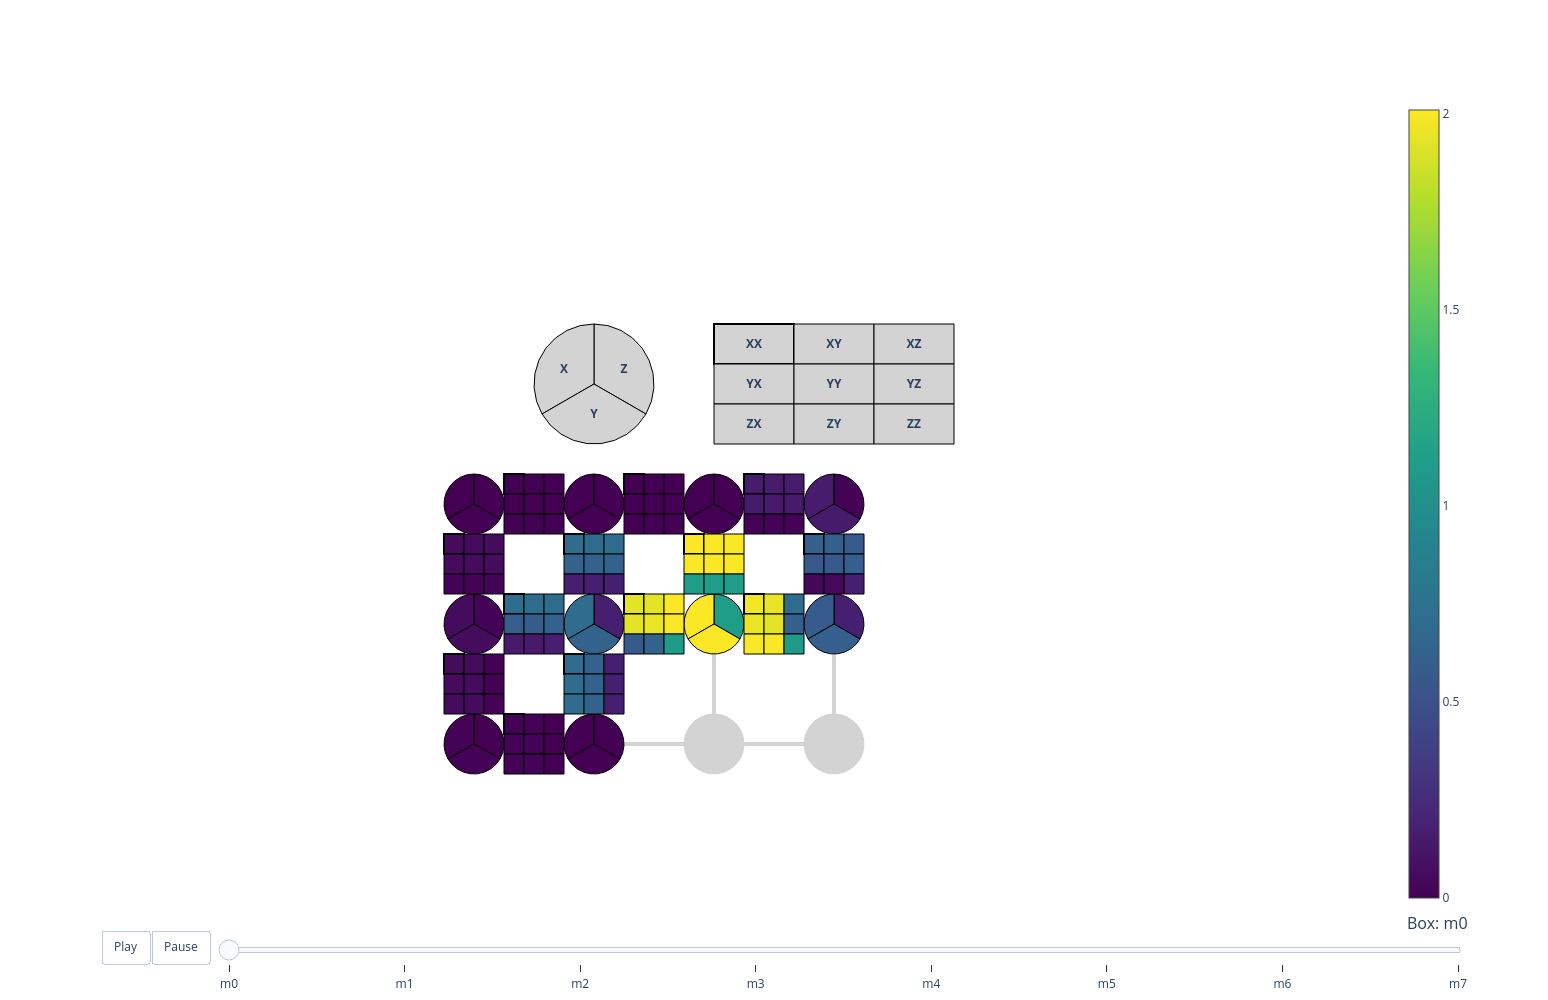

In [5]:
from qiskit import transpile
from qiskit.transpiler import CouplingMap
from qiskit_addon_slc.visualization import animate_shaded_lightcone

# A small square-lattice device stands in for a real backend here.
coupling_map = CouplingMap.from_grid(3, 4)

# Lay the chain onto a connected path of physical qubits, snaking through the grid, so the
# transpiler inserts no SWAPs: a SWAP-laden circuit is far more expensive to bound and harder to
# read.
initial_layout = [0, 1, 2, 3, 7, 6, 5, 4, 8, 9]
device_circuit = transpile(
    circuit,
    coupling_map=coupling_map,
    initial_layout=initial_layout,
    optimization_level=0,
)
boxed_device_circuit = boxing_pass.run(device_circuit)
device_noise_paulis = generate_noise_model_paulis(
    find_unique_box_instructions(boxed_device_circuit),
    coupling_map=coupling_map,
    circuit=boxed_device_circuit,
)
# The same observable, on the physical qubit the middle of the chain was laid onto.
device_observable = Pauli("I" * device_circuit.num_qubits).compose(
    "Z", [initial_layout[num_qubits // 2]]
)
device_bounds = compute_forward_bounds(boxed_device_circuit, device_noise_paulis, device_observable)

animate_shaded_lightcone(boxed_device_circuit, device_bounds, coupling_map)

### Reading the animation

**Each qubit is a pie chart, one slice per Pauli type.** A qubit's marker is divided into three
slices for its $X$, $Y$ and $Z$ errors, each shaded by its own bound. This is the filtering from the
previous section built into the figure (no `pauli_filter` needed to tell the types apart).

**Edges carry the two-qubit error bounds.** The line between two coupled qubits is shaded by the
bound on weight-2 errors acting on that pair.

**Light gray means no data, not a small bound.** A slice or an edge is drawn light gray when the
box's noise model has no error term for it, for instance on qubits the box does not act on. It is
drawn gray rather than dark so it cannot be confused with a bound of zero. Boxes beyond a
`max_num_boxes` limit are different: they carry the trivial bound of 2.0, so they are drawn at the
bright end of the scale.

**The slider steps through boxes, not through time uniformly.** There is one frame per noisy box, in
circuit order (or in reverse order with `reverse=True`, which traces the lightcone backwards from
the observable). Watching it in reverse is usually the more intuitive direction: the cone grows
outwards from the measured qubits. Each frame is labelled with its box's identifier, the same key
under which the bounds dictionary stores that box, so the slider can also be used to jump to a
particular box and look up its numbers.

<div class="alert alert-info">

**Note:** The qubit layout is recovered from the coupling map's graph by embedding it into a square
lattice. A coupling map that does not embed (because it is disconnected, or too densely connected
for a grid) raises a `ValueError` rather than drawing a misleading picture.

</div>

## Which to use

| | `draw_shaded_lightcone` | `animate_shaded_lightcone` |
| --- | --- | --- |
| geometry | the circuit diagram | the QPU coupling map |
| best for | 1D chains | any connectivity |
| Pauli types | summed, unless filtered | always split, as pie slices |
| time | all layers at once | one layer per frame |
| output | a `matplotlib` figure | a `plotly` figure |

For a 1D chain the static figure is easier to take in at a glance and reproduces in a paper. Beyond
1D the animation is the only one of the two that shows the spatial structure faithfully.